このページではTF-IDFとロジスティック回帰を使って英文フェイクニュースの識別を行う<br>
この機械学習で使うTF-IDFについて
# TF-IDF
参考元: <br>
https://qiita.com/ebimontblanc/items/80938fc8f56b5a0a9217 <br>
https://omomuki-tech.com/archives/6288 <br>
TF-IDFとは単語の出現頻度を数え上げるTF(Term Frequency)と、与えられた文章群の中で見たときに単語がどの程度希少なのかを計算するIDF(Inverse Document Frequency)を掛け合わせて、**単語の重要度を算出する**手法。<br>
*TF = 単語の出現回数 /  文章内の単語数*<br>
*IDF = log(全文書数 / (単語が出現した文書数 + 1) )*<br>
*TF-IDF = TF × IDF*
- メリット
    - **実装が比較的容易**
    - **結果の解釈がしやすい**
    - **様々な場面で効果的に利用できる**
- デメリット
    - **単語の意味や順序の情報を無視する**
    - **同義語や表記ゆれを別の単語として扱う**
    - 希少語の過大評価の可能性

ロジスティック回帰についてはベース資料の../FakeNewsMachineLearning.ipynbを参照してください。<br>
以上のTF-IDFとロジスティック回帰を用いて英文FakeNewsの分類を行ってみます。

作成した変数を取り出す

In [13]:
import pickle

with open("../../Data/train_test_split.pkl", "rb") as f:
    x_train, x_test, y_train, y_test = pickle.load(f)

追加の前処理としてNormalizeを行う

In [14]:
import re

def NormalizeText(text):
    text = text.lower() #小文字化
    text = text.replace('\n', ' ') #改行をスペース変換
    text = re.sub(r'[^\w\s]', '', text) #特殊文字を削除
    text = text.strip() #テキストの前後の空白を消去
    return text

x_train_Normalized = x_train.apply(NormalizeText)
x_test_Normalized = x_test.apply(NormalizeText)

TF-IDFを使ってデータを変換する

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

def Tfidf_Limit(limit, x_train, x_test):
    vectorizer = TfidfVectorizer(max_features = limit)
    x_train_tfidf = vectorizer.fit_transform(x_train)
    x_test_tfidf = vectorizer.transform(x_test)
    return x_train_tfidf, x_test_tfidf

x_train_tfidf, x_test_tfidf = Tfidf_Limit(5000, x_train_Normalized, x_test_Normalized)

ロジスティック回帰を使って学習

In [16]:
from sklearn.linear_model import LogisticRegression

def Learning(x_train_tfidf, y_train):
    model = LogisticRegression(max_iter=2000)
    model.fit(x_train_tfidf, y_train)
    return model

model = Learning(x_train_tfidf, y_train)

特徴量5000の時の結果を表示

In [17]:
from sklearn.metrics import classification_report, accuracy_score

def DispResult(model, x_test_tfidf, y_test):
    pred = model.predict(x_test_tfidf)
    print(classification_report(y_test, pred))
    print(accuracy_score(y_test, pred))
    
DispResult(model, x_test_tfidf, y_test)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3472
           1       0.98      0.99      0.99      4258

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730

0.986287192755498


精度と特徴量の関係をグラフにまとめると以下のようになる

[0.5604139715394567, 0.632470892626132, 0.696895213454075, 0.754980595084088, 0.754980595084088, 0.7840879689521345, 0.8714100905562743, 0.9294954721862871, 0.9768434670116429, 0.9840879689521346, 0.9838292367399741, 0.986287192755498]


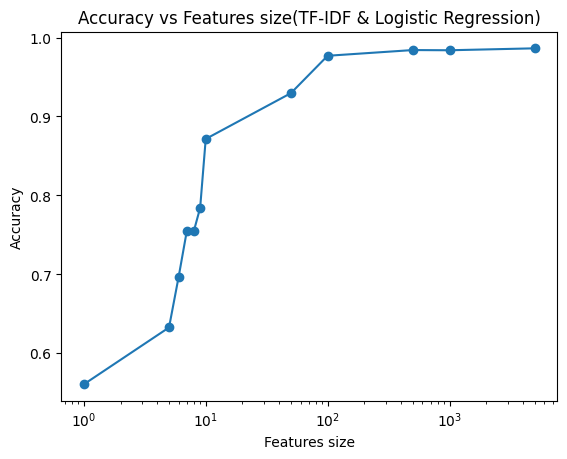

In [18]:
import matplotlib.pyplot as plt

def GetAccuracy(model, x_test_tfidf, y_test):
    y_pred = model.predict(x_test_tfidf)
    return accuracy_score(y_test, y_pred)

features_sizes = [1,5,6,7,8,9,10,50,100,500,1000,5000]
accuracies = [0] *  len(features_sizes)

for i in range(len(features_sizes)):
    x_train_tfidf, x_test_tfidf = Tfidf_Limit(features_sizes[i], x_train_Normalized, x_test_Normalized)
    model = Learning(x_train_tfidf, y_train)
    accuracies[i] = GetAccuracy(model, x_test_tfidf, y_test)

print(accuracies)

plt.plot(features_sizes, accuracies, marker="o")
plt.xlabel("Features size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Features size(TF-IDF & Logistic Regression)")
plt.xscale("log")
plt.show

plt.savefig("../../Figures/TF-IDF&LogisticRegression_accuracy_vs_features_size.png", dpi=300, bbox_inches="tight")

特徴量と処理時間の関係は以下のようになる。処理時間の計測は文章データのベクトル化とモデルの学習時間の総和とした。

[9.44668698310852, 8.853744506835938, 8.85611867904663, 8.86067271232605, 8.880304336547852, 9.085188865661621, 9.267988681793213, 9.325026988983154]


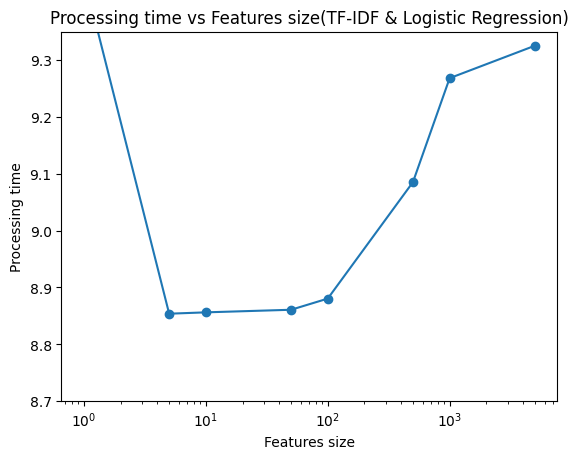

In [ ]:
import time

def measure_time(x_train_Normalized, x_test_Normalized, y_train, limit):
    start = time.time()
    x_train_tfidf, x_test_tfidf = Tfidf_Limit(limit, x_train_Normalized, x_test_Normalized)
    model = Learning(x_train_tfidf, y_train)
    end = time.time()
    return end - start

features_sizes = [1, 5, 10, 50, 100, 500, 1000, 5000]
processing_time = [0] * len(features_sizes)

for i in range(len(features_sizes)):
    processing_time[i] = measure_time(x_train_Normalized, x_test_Normalized, y_train, features_sizes[i])
    
print(processing_time)

plt.plot(features_sizes, processing_time, marker="o")
plt.xlabel("Features size")
plt.ylabel("Processing time")
plt.title("Processing time vs Features size(TF-IDF & Logistic Regression)")
plt.xscale("log")
plt.ylim(1,10)
plt.show

plt.savefig("../../Figures/TF-IDF&LogisticRegression_ProcessingTime_vs_features_size.png", dpi=300, bbox_inches="tight")
